## Output Parsers in LangChain

Convert the raw LLM Response into structured formats like JSON, CSV, Pydantic models, and more. They ensure consistency, validation and ease of use of applications. 

Output Parsers are components in LangChain that take the raw output generated by an LLM and convert it into a predictable, structured format that your application can actually use.

Think of an output parser as a translator between the LLM and your Python application.

LangChain provides different classes/components that help you process LLM output. Instead of manually writing parsing logic every time, you can use LangChain's existing parsers.

- We can use output parsers with can and can't models

Type 1 — Models that can generate structured output

Type 2 — Models that cannot reliably generate structured output

works for both

## Four types of Output Parsers

1. String output parsers
2. JSON output parsers
3. Structured output parsers
4. pydantic output parsers

## 1. StrOutputParser

Simplest output parser in Langchain. It is used to parse the output of LLM and return it as a plain string i.e Converts LLM responses into string

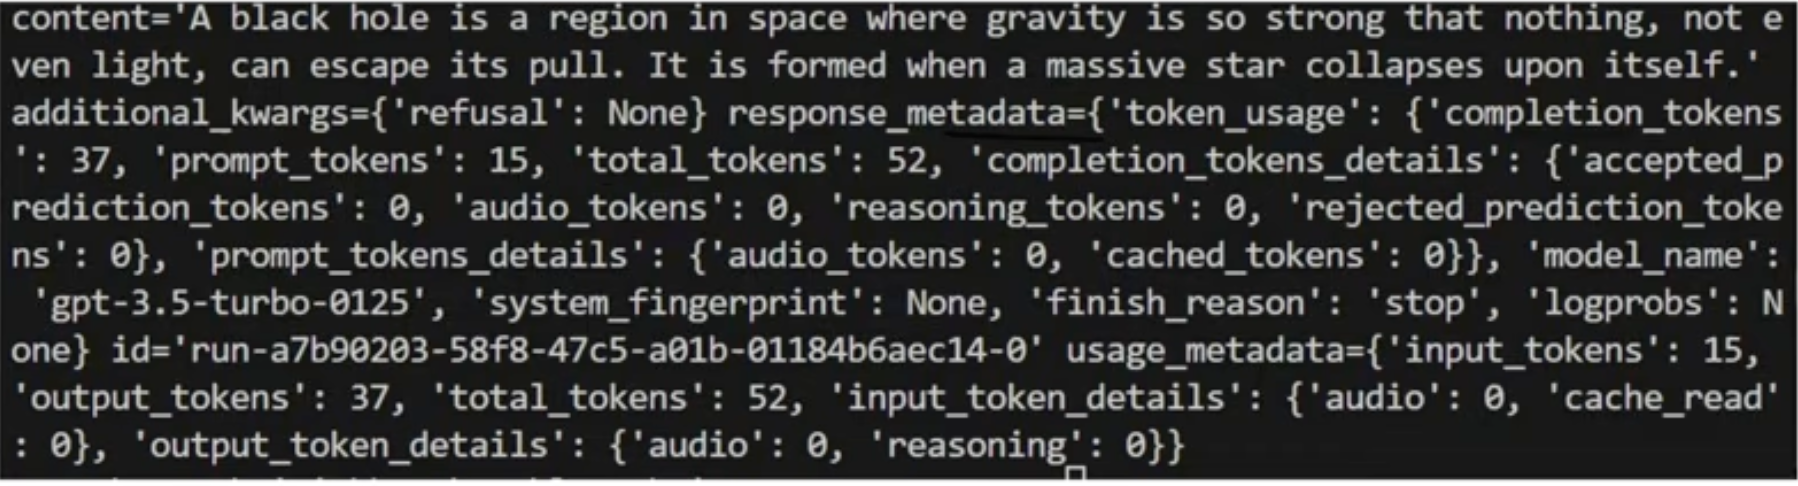



We not only get text response from llm but we also get meta data from llm response. After that we need to extract content attribute (result.content)

If you use StrOutputParser then you don’t have to use result.content, it will extract string from the whole result and will give textual response

# Why StrOurParser ?

if we can use result.content then why StrOutput Parser ?


Answer:

Example: we will communicate twice with the LLM 

topic -> LLM -> Detailed report -> LLM -> summarize 

Without StrOutputParser: 

In [4]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
load_dotenv()

True

In [8]:
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

## 1st prompt
template1=PromptTemplate(
    template='Write a detailed report on {topic}',
    input_variables=['topic']
)

prompt1=template1.invoke({'topic':'blackhole'})
result=model.invoke(prompt1)

## 2nd prompt 
template2=PromptTemplate(
    template='Write a five line summary on the following text. /n {text}',
    input_variables=['text']
)
prompt2=template2.invoke({'text':result.content})

result1=model.invoke(prompt2)
print(result1.content[0]['text'])

Predicted by General Relativity, black holes are regions of spacetime with gravity so intense that nothing, including light, can escape.

Their anatomy features a dense central singularity surrounded by an event horizon boundary, a photon sphere, and frequently an accretion disk.

Categorized by mass from micro to supermassive, black holes exhibit extreme phenomena like gravitational time dilation, spaghettification, and eventual Hawking evaporation.

Scientists detect these invisible objects indirectly through stellar dynamics, high-energy X-ray emissions, gravitational waves, and direct radio imaging by the Event Horizon Telescope.

Serving as critical drivers of galaxy formation, black holes remain key to modern astrophysics as researchers work to unify general relativity with quantum mechanics.


With StrOutputParser 

Much Easier and Cleaner code

Different approach:

StrOutputParser: Whenever the LLM produces a response in this chain, automatically convert its output into a string.

result.content: I already have the model's response. Give me the text inside this response.

In [ ]:
from langchain_core.output_parsers import StrOutputParser
## 1st prompt
template1=PromptTemplate(
    template='Write a detailed report on {topic}',
    input_variables=['topic']
)
## 2nd prompt 
template2=PromptTemplate(
    template='Write a five line summary on the following text. /n {text}',
    input_variables=['text']
)
parser=StrOutputParser() ## creating object of string output parser


In [13]:

## I can create a chain. Chain is basically a pipeline where we completely execute the flow
## user will fill something in template 1 ex blackhole then this goes to model and model processes it and give response
## that response can have meta data and other data, parser will extract imp string information and gives detailed report
## we send detailed report to template 2 and send it to model again 
chain = template1 | model | parser | template2 | model | parser 


result=chain.invoke({'topic':'black hole'})
print(result)

Black holes are regions of spacetime with gravity so intense that nothing, including light, can escape their gravitational pull.
Predicted by Einstein's General Relativity, they range from micro to supermassive scales and feature an event horizon surrounding a central singularity.
They primarily form through the gravitational collapse of massive stars and expand by accreting surrounding matter or merging with other compact objects.
These objects display unique physical phenomena, including spaghettification, quantum Hawking radiation, and the unresolved black hole information paradox.
Once purely theoretical, their physical existence is now confirmed by gravitational wave detections and direct imaging from the Event Horizon Telescope.


## 2. JSONOutputParser

JsonOutputParser is used when you want the LLM's response in JSON format.

In [14]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
load_dotenv()

True

In [15]:
## Whenever you use parsers like JsonOutputParser or StructuredOutputParser,  while creating the prompt,
## you give additonal information (which output you want from LLM)
## parser.get_format_instructions() -> parser tells you what format you want .. this gets filled before run time


In [29]:
from langchain_core.output_parsers import JsonOutputParser
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
parser=JsonOutputParser()
template=PromptTemplate(
    template="Give me the name,age and city of a fictional person \n {format_instruction}",
    partial_variables={'format_instruction':parser.get_format_instructions()},
    input_variables=[]
)

prompt=template.format() ## can use template.invoke() also 
result=model.invoke(prompt)

In [30]:
prompt

'Give me the name,age and city of a fictional person \n Return a JSON object.'

In [ ]:
result

## AIMessage(content=[{'type':'text','text': '```json\n{\n  "name": "Clara Vance",\n  "age": 29,\n  "city": "Seattle"\n}\n```'}])
# result
# │
# └── AIMessage
#       │
#       └── content
#             │
#             └── list
#                  │
#                  └── dictionary
#                       │
#                       └── "text"

## parser.parse(x) x must be a string 

AIMessage(content=[{'type': 'text', 'text': '```json\n{\n  "name": "Clara Vance",\n  "age": 29,\n  "city": "Seattle"\n}\n```', 'extras': {'signature': 'EtMFCtAFARFNMg//w5c94qIvzKWg25KZQpeySFF0hJpBkouzuQOQdPqw2u8r7d9UpajKzvNV4BJm4w5fDkEbKYIvUeF15uU5idRLwlzkZp7fJ0WFesbIMHyDXxYT6mUM1bdkuyw7sMAdxibks1TVg5R/ST0dMJmjwih7aGY5/4KSDR8bqUvGdhUuN/LIH2x+0oN62r2shyy2YTzEULBtcroEo0cgkDshRqfIgX50bmX5qD/PZjyA9q+VZQyqlLTALIzMSfSYpYHKiW6V93Mfc0tNiWHoY6QXiUdRbv75kQ3cVjbgPTIPFSQ897X9OwxmwdjRYo/LhoW9dFi7LhlHYSTc+sy6MGCMCbZmFGKdZ3jCtSyHG6iiGMf/KgQwnhEJ07Sp7LzQrhGok3G9tqjf6MMhyE1SNmHzcW7yzpxQum1Lx2mFjO2nAB0vjXxl7P3CBeRrvIme8x/JYSRsDsUyeCYSO2M6raOHdL/fecEpG6LNB7zOuYlW/N2a72FQF0gNT1NJL3zOMGyV0++Vv0Ln5DF6NnNJvLp0x8r06BzAUdgf6ZaEZ0Ha5RCiR2NyZj83hK/UsWvGy1xQg4OlFWPsSA0wIj2hCAisQhFh6IdWiWY9UkqtdS76+zKyMwhvJyJWQAMbd6R4GfOJ/Z9NRACMHzXbSNEZkuHycul8F6xMzNRU2OVfqY/zYBOGqNlJxBjjHhThP9XY4QJzCzKKlpmMofkNnahsM/I0EPm/Een/aWktpCgnMGVfHOR51ghGRynoePnn/uAQwgEMGndiqMdScOdld1l6mgNSw5NMIyJ3bjsk4JjHr2JmkxhvU2wc/gDoqJC72lZavPAeW5UM

In [ ]:
parser.invoke(result)

# invoke() is the Runnable interface of LangChain parsers. 
# The Python BaseOutputParser.invoke() accepts either a string or a BaseMessage

{'name': 'Clara Vance', 'age': 29, 'city': 'Seattle'}

In [ ]:
type(parser.invoke(result))

dict

## Alternative way of writing code

In [41]:
from langchain_core.output_parsers import JsonOutputParser
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
parser=JsonOutputParser()

template=PromptTemplate(
    template="Give me the name,age and city of a fictional person \n {format_instruction}",
    partial_variables={'format_instruction':parser.get_format_instructions()},
    input_variables=[]  
)

chain= template | model | parser
result=chain.invoke({}) ## didn't invoke anything that's why blank dictionary
print(result)

{'name': 'Elena Rostova', 'age': 29, 'city': 'Seattle'}


## Problem with JsonOutputParser:

You can get JSON object from JsonOutputParser with the help of LLM, but you cannot enforce a strict schema means we cannot tell the structure of Json object

In [42]:
template=PromptTemplate(
    template="Give me 5 facts about {topic} \n {format_instruction}",
    partial_variables={'format_instruction':parser.get_format_instructions()},
    input_variables=['topic']  
)
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
parser=JsonOutputParser()

chain = template | model | parser 

result=chain.invoke({'topic':'Marvel'})
print(result)

{'marvel_facts': ['Marvel Comics was originally founded in 1939 by Martin Goodman under the name Timely Publications.', 'The Hulk was originally gray in his 1962 debut, but printer color inconsistencies forced Stan Lee to change his skin tone to green.', 'Michael Jackson attempted to buy Marvel Comics in the 1990s primarily because he wanted to star as Spider-Man in a movie.', "Robert Downey Jr. improvised the iconic line 'I am Iron Man' at the end of the 2008 film, which ultimately shaped the direction of the Marvel Cinematic Universe.", "Marvel and DC Comics jointly held the official trademark for the word 'Super Hero' from 1979 until late 2024."]}


In [ ]:
result

## I get a key and inside key I get all the facts but what if I want this stucture

## {'fact1':.........
##  'fact2':........
##   'fact3:....... 
##   }

## we cannot do this

{'marvel_facts': ['Marvel Comics was originally founded in 1939 by Martin Goodman under the name Timely Publications.',
  'The Hulk was originally gray in his 1962 debut, but printer color inconsistencies forced Stan Lee to change his skin tone to green.',
  'Michael Jackson attempted to buy Marvel Comics in the 1990s primarily because he wanted to star as Spider-Man in a movie.',
  "Robert Downey Jr. improvised the iconic line 'I am Iron Man' at the end of the 2008 film, which ultimately shaped the direction of the Marvel Cinematic Universe.",
  "Marvel and DC Comics jointly held the official trademark for the word 'Super Hero' from 1979 until late 2024."]}

## StructuredOutputParser

Output parser in langchain that helps extract structured Json data from LLM response based on predefined final schema

Difference btw Structuredoutputparser and jsonoutputparser is :

in structureoutputparser, you provide schema but in jsonoutputparser you cannot provide predefined schema 

It works by enforcing a list of fields (ResponseSchema) that the model should return, ensuring the output follows a structured format.

In [44]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
load_dotenv()

True

In [ ]:
## langchain_core is a small library where key components are there

## langchain is superset of langchain_core library 

In [50]:
from langchain.output_parsers import StructuredOutputParser, ResponseSchema
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
schema=[
ResponseSchema(name='fact1',description='Fact 1 about the topic'),
ResponseSchema(name='fact2',description='Fact 2 about the topic'),
ResponseSchema(name='fact3',description='Fact 3 about the topic'),
ResponseSchema(name='fact4',description='Fact 4 about the topic'),
ResponseSchema(name='fact5',description='Fact 5 about the topic'),
]

parser=StructuredOutputParser.from_response_schemas(schema)
template=PromptTemplate(
    template="Give 5 facts about the {topic} \n {format_instruction}",
    input_variables=['topic'],
    partial_variables={'format_instruction':parser.get_format_instructions()}
)

prompt=template.invoke({'topic':'black hole'}) ## can use template.invoke() also 
result=model.invoke(prompt)

In [52]:
parser.invoke(result)

{'fact1': 'Black holes are regions of spacetime where gravity is so intense that nothing, not even light, can escape from them.',
 'fact2': 'The boundary surrounding a black hole from which nothing can escape is called the event horizon.',
 'fact3': 'The first direct image of a black hole, located in the galaxy M87, was captured by the Event Horizon Telescope and released in 2019.',
 'fact4': 'At the center of a black hole lies a gravitational singularity, a point where matter is crushed into infinite density and known laws of physics break down.',
 'fact5': 'Black holes can slowly lose mass and eventually evaporate over time through a theoretical process known as Hawking radiation.'}

## Alternative short way

In [53]:
from langchain.output_parsers import StructuredOutputParser, ResponseSchema
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
schema=[
ResponseSchema(name='fact1',description='Fact 1 about the topic'),
ResponseSchema(name='fact2',description='Fact 2 about the topic'),
ResponseSchema(name='fact3',description='Fact 3 about the topic'),
ResponseSchema(name='fact4',description='Fact 4 about the topic'),
ResponseSchema(name='fact5',description='Fact 5 about the topic'),
]

parser=StructuredOutputParser.from_response_schemas(schema)
template=PromptTemplate(
    template="Give 5 facts about the {topic} \n {format_instruction}",
    input_variables=['topic'],
    partial_variables={'format_instruction':parser.get_format_instructions()}
)

chain = template | model | parser 

result=chain.invoke({'topic':'Avengers'})
print(result)

{'fact1': 'The Avengers first appeared in comic books in September 1963, created by writer Stan Lee and artist Jack Kirby.', 'fact2': 'The original founding members in the comics were Iron Man, Thor, Ant-Man, the Wasp, and the Hulk; Captain America did not join until issue #4.', 'fact3': "Janet van Dyne, also known as the Wasp, was the character who actually came up with the name 'The Avengers'.", 'fact4': "The team's iconic battle cry, 'Avengers Assemble!', was first spoken in the comics by Thor in 1965.", 'fact5': "The 2012 film 'The Avengers' was the first Marvel Cinematic Universe movie to cross $1 billion at the box office worldwide."}


## Disadvantages of StructuredOutputParser:

## No data validation :

Suppose you want a dict like this : name: str , age:int 

LLM gives you response but in that response age= "35 years" which is string and we do not have any way to validate the results

## PydanticOutputParser

Structured OutputParser in LangChain that uses Pydantic Models to enforce schema validation when processing LLM response. 

## Why PydanticOutputParser ?

1. Strict Schema Enforcement -> Ensures LLM response follows a strict well defined structure

2. Type Safety -> Automatically converts LLM outputs to pydantic objects

3. Easy Validation -> Pydantic's builtin validation to catch incorrect or missing data

4. Seamless integration -> works well with other Langchain components

In [2]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel,Field
load_dotenv()


True

In [58]:
class Person(BaseModel):
    name:str = Field(description='Name of the person')
    age: int = Field(gt=18,description='age of the person')
    city: str= Field(description='Name of the city, the person belongs to ')

model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
parser=PydanticOutputParser(pydantic_object=Person)
template=PromptTemplate(
    template="Generate the name,age and city of a fictional {place} person \n {format_instruction}",
    input_variables=['place'],
    partial_variables={'format_instruction':parser.get_format_instructions()}
)


prompt=template.invoke({'place':'Indian'})
result=model.invoke(prompt)
result=parser.invoke(result)
print(result)


name='Aarav Sharma' age=28 city='Bengaluru'


In [59]:
print(prompt)

text='Generate the name,age and city of a fictional Indian person \n The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"name": {"description": "Name of the person", "title": "Name", "type": "string"}, "age": {"description": "age of the person", "exclusiveMinimum": 18, "title": "Age", "type": "integer"}, "city": {"description": "Name of the city, the person belongs to ", "title": "City", "type": "string"}}, "required": ["name", "age", "city"]}\n```'


In [3]:
class Person(BaseModel):
    name:str = Field(description='Name of the person')
    age: int = Field(gt=18,description='age of the person')
    city: str= Field(description='Name of the city, the person belongs to ')

model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')
parser=PydanticOutputParser(pydantic_object=Person)
template=PromptTemplate(
    template="Generate the name,age and city of a fictional {place} person \n {format_instruction}",
    input_variables=['place'],
    partial_variables={'format_instruction':parser.get_format_instructions()}
)


chain = template | model | parser
chain.invoke({'place':'American'})


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Person(name='Sarah Jenkins', age=34, city='Chicago')